In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import matplotlib.pyplot as plt 
from safetensors.torch import load_file
from pathlib import Path
from transformers import AutoTokenizer
from torch.utils.data import DataLoader
# customi imports
from simpledesign.models.simpledesign import SimpleDesign
from simpledesign.data.dataset import ProteinCollator, ProteinDataset

/Users/thomasbush/Documents/ML/simpledesign/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Loading the Model**

Since we initialize the sequence track using ESM2 weights, we have to build the model using parameters that match the one used for ESM2. In this case we are loading a 8M version that needs:

- model dimension: 320
- num_heads: 20
- number of blocks: 6
- MLP dimension: 1280 (4*model_d)

By doing this we are initializing the sequence track. 

In [3]:
# load the model from a version of esm2: 
model = SimpleDesign(model_d=320, n_blocks=6, num_heads=20, mlp_d=1280, sigma=1.0)
model.load_esm2(load_file("/Users/thomasbush/Documents/ML/simpledesign/checkpoints/esm2_t6_8M_UR50D/model.safetensors"))

**Forward Pass**

To make a forward pass the model needs: 

- Sequences (B, L, )
- Coordinates (B, L, 3) + <cls>, <eos> pad slots 
- Sequence Mask real tokens
- Structure Mask  with pos 0 and l-1 for the special slots + pad
- idx: arange(L)-> the idx for each component in the sequence
- t and t' (B,)

## Testing the Model


To test the model we are going to load a sequence + structure

- Build the parsers
- Create a simple data loader -> convert to the right dims (add noise later)
- Do a forward pass

In [4]:
# load the data: 
CK = "../checkpoints/esm2_t6_8M_UR50D"
DATA = "/Users/thomasbush/Downloads/data_test_simpledesign"

ds = ProteinDataset(DATA)
ds.validate()

In [5]:
help(ProteinCollator)

Help on class ProteinCollator in module simpledesign.data.dataset:

class ProteinCollator(builtins.object)
 |  ProteinCollator(tokenizer, max_len: int | None = None)
 |
 |  Batch ProteinDataset items into SimpleDesign inputs (clean, uncorrupted).
 |
 |  tokenizer: the ESM2 tokenizer, e.g.
 |  AutoTokenizer.from_pretrained("checkpoints/esm2_t6_8M_UR50D").
 |  max_len: proteins longer than this are cropped to a random contiguous window of max_len
 |  residues, re-centered on its CA centroid. None: no cropping.
 |  Output (L = longest (cropped) protein + 2 for <cls>/<eos>):
 |      ids          list[str]
 |      seq          (B, L) long   ESM2 token ids, <pad> = 1
 |      seq_mask     (B, L) bool   real tokens incl. <cls>/<eos>
 |      struct_mask  (B, L) bool   real residues only
 |      coords       (B, L, 3)     CA coordinates at residue slots, 0 at <cls>/<eos>/pad
 |      b_factor     (B, L)        per-residue b-factor at residue slots, 0 elsewhere
 |      idx          (B, L) long   0

In [6]:
# build a small batch for our model
tok = AutoTokenizer.from_pretrained(CK)
loader = DataLoader(ds, batch_size=4, shuffle=True, collate_fn=ProteinCollator(tok))
batch = next(iter(loader))

In [7]:
batch.keys()

dict_keys(['ids', 'seq', 'seq_mask', 'struct_mask', 'coords', 'b_factor', 'idx'])

In [8]:
# test a forward pass: 
B = batch["seq"].shape[0] # get batch size 

logits, velocity = model(
    batch["seq"], batch["coords"], batch["seq_mask"], batch["struct_mask"], batch["idx"], t=torch.rand(B), t_prime=torch.rand(B))

In [9]:
velocity.shape

torch.Size([4, 130, 3])

In [19]:
seq_mask = batch["seq_mask"][1]
struct_mask = batch["struct_mask"][1]

seq = torch.ones(struct_mask.shape)
seq[struct_mask] = 32 

start, end = (seq_mask & ~struct_mask).nonzero()
seq[start] = 0
seq[end]=2
seq

tensor([ 0., 32., 32., 32., 32., 32., 32., 32., 32., 32., 32., 32., 32., 32.,
        32., 32., 32., 32., 32., 32., 32., 32., 32., 32., 32., 32., 32., 32.,
        32., 32., 32., 32., 32., 32., 32., 32., 32., 32., 32., 32., 32., 32.,
        32., 32., 32., 32., 32., 32., 32., 32., 32., 32., 32., 32., 32., 32.,
        32., 32., 32., 32., 32., 32., 32., 32., 32., 32., 32., 32., 32., 32.,
        32., 32., 32., 32., 32., 32., 32., 32., 32., 32., 32., 32., 32., 32.,
        32., 32., 32., 32., 32., 32., 32., 32., 32., 32., 32., 32., 32., 32.,
        32., 32., 32., 32., 32., 32., 32., 32., 32., 32., 32., 32., 32., 32.,
        32., 32., 32., 32., 32., 32., 32., 32., 32., 32., 32., 32.,  2.,  1.,
         1.,  1.,  1.,  1.])

## lData Corruption and Training 


Now that we have tested that the model can perform a forward pass, we have to: 

- Write the timestep data corruption to sample the noise levels
- Write the rigid target alignment algorithm to score correctly the predicted coordinates
- Write the loss function and a training loop

### Timestep Corruption 

- Structure: $x_{t'} = (1-t') \epsilon + x_0$  where $\epsilon$ is random noise
- Sequence: each residue is masked with probability $1-t$

 We need to draw a value for protein (B,): 

 - t-> torch.rand(B)
 - t' : mix of Beta and uniform


 **Sequence Corruption**
 seq_noise_mask = (torch.rand(B, L) < (1-t)[:, None]) & struct_mask (to keep only real tokens) 


 **Structure Corruption**

 

In [33]:
batch.keys()

dict_keys(['ids', 'seq', 'seq_mask', 'struct_mask', 'coords', 'b_factor', 'idx'])

In [34]:
def sample_timesteps(B, device):
    t = torch.rand(B, device=device)
    use_beta = torch.rand(B, device=device) < 0.98
    beta = torch.distributions.Beta(1.9, 1.0).sample((B,)).to(device)
    uniform = torch.rand(B, device=device)
    t_prime = torch.where(use_beta, beta, uniform)
    return t, t_prime

def corrupt(batch, t, t_prime):
    B = batch["seq"].shape[0]
    L = batch["seq"].shape[-1]
    dev = batch["seq"].device
    seq_noise_mask = (torch.rand(B, L, device=dev) < (1-t)[:, None]) & batch["struct_mask"]
    seq_t = batch["seq"].masked_fill(seq_noise_mask, 32)
    x_clean = batch["coords"]/10
    epsilon = torch.randn(B, L, 3, device=dev)
    # set zero outside the mask
    m = batch["struct_mask"][..., None].to(epsilon.dtype)       # (B, L, 1): 1 at real
    epsilon = epsilon * m                                       # zero padding / <cls> /
    c = epsilon.sum(dim=1, keepdim=True) / m.sum(dim=1, keepdim=True)   # (B, 1, 3):
    epsilon = (epsilon - c) * m
    # interpolate 
    x_prime = (1-t_prime)[:, None, None] * epsilon + t_prime[:, None, None] * x_clean
    # get velocity target: 
    v = x_clean - epsilon 
    return seq_t, x_prime, seq_noise_mask, v, epsilon

In [35]:
batch["coords"][0].mean(dim=0)


tensor([ 1.4672e-08, -9.5367e-08, -3.6680e-09])

In [36]:
# alignment algorithm: Kabsch algorithm
def structure_rigid_alignment(coords, ref_coords, mask):
    """Kabsch: rotate + translate `coords` onto `ref_coords`, per protein.

    coords, ref_coords: (B, L, 3); mask: (B, L) bool, True at real residues.
    Returns the aligned coords (B, L, 3), zero outside the mask. Proper rotations only
    (no reflections). Wrap the call in torch.no_grad() when used inside the loss.
    """
    m = mask[..., None].to(coords.dtype)                               # (B, L, 1)
    n = m.sum(dim=1, keepdim=True)                                     # (B, 1, 1)
    # centroids over real residues only
    mu = (coords * m).sum(dim=1, keepdim=True) / n                     # (B, 1, 3)
    mu_ref = (ref_coords * m).sum(dim=1, keepdim=True) / n
    x = (coords - mu) * m
    x_ref = (ref_coords - mu_ref) * m
    # cross-covariance H = sum_l x_ref_l (outer) x_l, then SVD per protein
    H = torch.einsum("bli,blj->bij", x_ref, x)                         # (B, 3, 3)
    U, S, Vh = torch.linalg.svd(H)
    # reflection fix, per protein: flip the last axis where det(U Vh) = -1
    d = torch.sign(torch.linalg.det(U @ Vh))                           # (B,)
    D = torch.diag_embed(torch.stack((torch.ones_like(d), torch.ones_like(d), d),dim=-1))
    R = U @ D @ Vh                                                     # (B, 3, 3),rotates x onto x_ref
    # coordinates are row vectors: x_aligned = x R^T, then move to the reference centroid
    return (x @ R.transpose(-1, -2) + mu_ref) * m


def aligned_velocity_target(x_clean, eps, coords_t, v_pred, t_prime, struct_mask):
    """Rotate/translate the ground truth onto the model's predicted structure, rebuild the target."""
    with torch.no_grad():
        x1_hat = coords_t + (1 - t_prime)[:, None, None] * v_pred          # predicted clean structure
        x1_aligned = structure_rigid_alignment(x_clean, x1_hat, struct_mask)
    m = struct_mask[..., None].to(x_clean.dtype)
    return (x1_aligned - eps) * m


### Training Loop

Now we can sample the noise levels, compute a forward pass and train the model, first we need to build our loss functions: 

- Sequence: linear-weighted negative log likelihood of masked amino-acids given the partially observed sequence -> cross entropy
- Struture: Mean Square Root Error between the velocity fields 
- Joint: the weighted sum, parametrized by $\lambda_a, \lambda_x$ for sequence and structure objective respectively

In [37]:
import torch.nn.functional as F
AA_IDS = slice(4, 24)

In [38]:
def joint_loss(
    logits,          # (B, L, 33) sequence head output
    seq,             # (B, L) long, CLEAN tokens (batch["seq"])
    noise_mask,      # (B, L) bool, residues replaced by <mask>
    v_pred,          # (B, L, 3) predicted velocity (nm)
    v_true,          # (B, L, 3) target velocity x1 - x0 (nm)
    struct_mask,     # (B, L) bool, real residues
    beta=None,       # (B,) sequence time weight beta(t); None -> 1
    lambda_seq=1.0,
    lambda_struct=1.0,
    aa_only=True,    # restrict the softmax to the 20 amino acids
):
    """lambda_seq * L_CE + lambda_struct * L_MSE. Returns (total, {"seq", "struct"}
detached)."""
    B = seq.shape[0]

    # --- sequence: beta(t) * mean CE over masked tokens, per protein, then batch mean
    logits = logits.float()
    if aa_only:
        restricted = torch.full_like(logits, float("-inf"))
        restricted[..., AA_IDS] = logits[..., AA_IDS]
        logits = restricted
    ce = F.cross_entropy(logits.transpose(1, 2), seq, reduction="none")      # (B,L)
    ce = ce.masked_fill(~noise_mask, 0.0)                                     # drop non-masked (incl. inf at specials)
    seq_per_protein = ce.sum(1) / noise_mask.sum(1).clamp(min=1)              # (B,)
    if beta is None:
        beta = torch.ones(B, device=seq.device)
    seq_obj = (beta * seq_per_protein).mean()

    # --- structure: squared L2 per residue, mean over real residues, per protein, then batch mean
    se = ((v_pred.float() - v_true.float()) ** 2).sum(-1)                     # (B,L)
    struct_obj = ((se * struct_mask).sum(1) / struct_mask.sum(1).clamp(min=1)).mean()

    total = lambda_seq * seq_obj + lambda_struct * struct_obj
    return total, {"seq": seq_obj.detach(), "struct": struct_obj.detach()}

### Training Loop

Now we that have the model, data loader and corruption function and the objective function we can run our model


- define optimizer

- 

In [39]:
device="mps"
for key, item in batch.items():
    if isinstance(item, torch.Tensor):
        batch[key] = item.to(device)

In [40]:
N_STEPS = 10_000
FIXED_CORRUPTION = False     # stage 1: True (memorize one corruption); stage 2: False (fresh noise every step)
LR = 1e-4
LOG_EVERY = 1_000
torch.manual_seed(0)

model = model.to(device).train()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.0)
x_clean = batch["coords"] /10

def masked_accuracy(logits, seq, noise_mask):
    pred = logits[..., AA_IDS].argmax(-1) + AA_IDS.start
    return (pred == seq)[noise_mask].float().mean()


# ---------------------------------------------------------------- training: loop
B = batch["seq"].shape[0]
if FIXED_CORRUPTION:
    t, t_prime = sample_timesteps(B, device)
    seq_t, coords_t, noise_mask, v_target, x0 = corrupt(batch, t, t_prime)
    seq_t = seq_t.to(device)
    coords_t = coords_t.to(device)
    noise_mask = noise_mask.to(device)
    v_target = v_target.to(device)
    x0 = x0.to(device)
    print(f"fixed corruption: t={[round(x, 2) for x in t.tolist()]} "
          f"t'={[round(x, 2) for x in t_prime.tolist()]} masked={int(noise_mask.sum())}")

history = []
for step in range(N_STEPS + 1):
    if not FIXED_CORRUPTION:
        t, t_prime = sample_timesteps(B, device)
        seq_t, coords_t, noise_mask, v_target, x0 = corrupt(batch, t, t_prime)

    logits, velocity = model(seq_t, coords_t, batch["seq_mask"], batch["struct_mask"],
                             batch["idx"], t, t_prime)
    v_aligned = aligned_velocity_target(x_clean, x0, coords_t, velocity, t_prime, batch["struct_mask"])
    total, parts = joint_loss(logits, batch["seq"], noise_mask, velocity, v_aligned,
                              batch["struct_mask"])

    optimizer.zero_grad(set_to_none=True)
    total.backward()
    grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    history.append({
        "step": step, "total": total.item(), "seq": parts["seq"].item(),
        "struct": parts["struct"].item(),
        "acc": masked_accuracy(logits.detach(), batch["seq"], noise_mask).item(),
        "grad_norm": grad_norm.item(), "t": t.tolist(), "t_prime": t_prime.tolist(),
    })
    if step % LOG_EVERY == 0:
        h = history[-1]
        print(f"step {step:4d} | total {h['total']:.4f} | seq {h['seq']:.4f} acc {h['acc']:.2f} "
              f"| struct {h['struct']:.4f} | |g| {h['grad_norm']:.1f}")

step    0 | total 8.3742 | seq 2.7473 acc 0.12 | struct 5.6269 | |g| 20.0
step 1000 | total 0.9142 | seq 0.0169 acc 1.00 | struct 0.8973 | |g| 6.9
step 2000 | total 0.5585 | seq 0.0019 acc 1.00 | struct 0.5566 | |g| 14.6
step 3000 | total 0.1638 | seq 0.0010 acc 1.00 | struct 0.1627 | |g| 5.5
step 4000 | total 0.6797 | seq 0.0007 acc 1.00 | struct 0.6791 | |g| 16.0
step 5000 | total 0.1483 | seq 0.0012 acc 1.00 | struct 0.1471 | |g| 5.4
step 6000 | total 0.2052 | seq 0.0003 acc 1.00 | struct 0.2049 | |g| 5.4
step 7000 | total 0.1037 | seq 0.0005 acc 1.00 | struct 0.1032 | |g| 5.0
step 8000 | total 0.8367 | seq 0.0003 acc 1.00 | struct 0.8364 | |g| 6.2
step 9000 | total 0.1102 | seq 0.0001 acc 1.00 | struct 0.1100 | |g| 4.3
step 10000 | total 0.2134 | seq 0.0001 acc 1.00 | struct 0.2133 | |g| 6.1


In [41]:
import numpy as np
def plot_history(history, smooth=1, t_bins=(0.0, 0.3, 0.7, 1.0)):
    """Plot a training `history` (list of dicts from the training loop).

    Row 1: sequence CE, structure MSE (log scale), masked-residue accuracy, grad norm.
    Row 2 (only if the noise levels vary between steps, i.e. stage 2): per-step losses binned by
    the batch-mean t (sequence) and t' (structure), showing where the model still struggles.
    smooth: moving-average window in steps (1 = raw).
    """
    steps = np.array([h["step"] for h in history])

    def series(key):
        y = np.array([h[key] for h in history], dtype=float)
        if smooth > 1 and len(y) >= smooth:
            y = np.convolve(y, np.ones(smooth) / smooth, mode="valid")
            return steps[smooth - 1:], y
        return steps, y

    t_mean = np.array([np.mean(h["t"]) for h in history])
    tp_mean = np.array([np.mean(h["t_prime"]) for h in history])
    varying = np.ptp(tp_mean) > 0 or np.ptp(t_mean) > 0

    fig, axes = plt.subplots(2 if varying else 1, 4, figsize=(18, 7.5 if varying else 3.8), squeeze=False)
    panels = [("seq", "sequence CE (masked)", True), ("struct", "structure MSE (nm²)", True),
              ("acc", "masked-residue accuracy", False), ("grad_norm", "grad norm (pre-clip)", True)]
    for ax, (key, title, log) in zip(axes[0], panels):
        x, y = series(key)
        ax.plot(x, y, lw=1.2)
        ax.set_title(title)
        ax.set_xlabel("step")
        if log:
            ax.set_yscale("log")
        if key == "acc":
            ax.set_ylim(0, 1.02)
        ax.grid(alpha=0.3)

    if varying:
        edges = np.array(t_bins)
        for ax, key, tv, name in ((axes[1][0], "seq", t_mean, "t"), (axes[1][1], "struct", tp_mean, "t'")):
            y = np.array([h[key] for h in history])
            for lo, hi in zip(edges[:-1], edges[1:]):
                sel = (tv >= lo) & (tv < hi) if hi < 1 else (tv >= lo) & (tv <= hi)
                if sel.any():
                    ax.scatter(steps[sel], y[sel], s=6, alpha=0.5, label=f"{name} ∈ [{lo:.1f}, {hi:.1f})  n={sel.sum()}")
            ax.set_yscale("log")
            ax.set_title(f"{key} loss per step, colored by batch-mean {name}")
            ax.set_xlabel("step")
            ax.legend(fontsize=8)
            ax.grid(alpha=0.3)
        for ax, key, tv, name in ((axes[1][2], "seq", t_mean, "t"), (axes[1][3], "struct", tp_mean, "t'")):
            last = slice(len(history) // 2, None)  # second half of training: the plateau
            ax.scatter(tv[last], np.array([h[key] for h in history])[last], s=8, alpha=0.6)
            ax.set_yscale("log")
            ax.set_title(f"{key} loss vs {name} (second half of training)")
            ax.set_xlabel(f"batch-mean {name}  (1 = clean)")
            ax.grid(alpha=0.3)

    fig.tight_layout()
    return fig

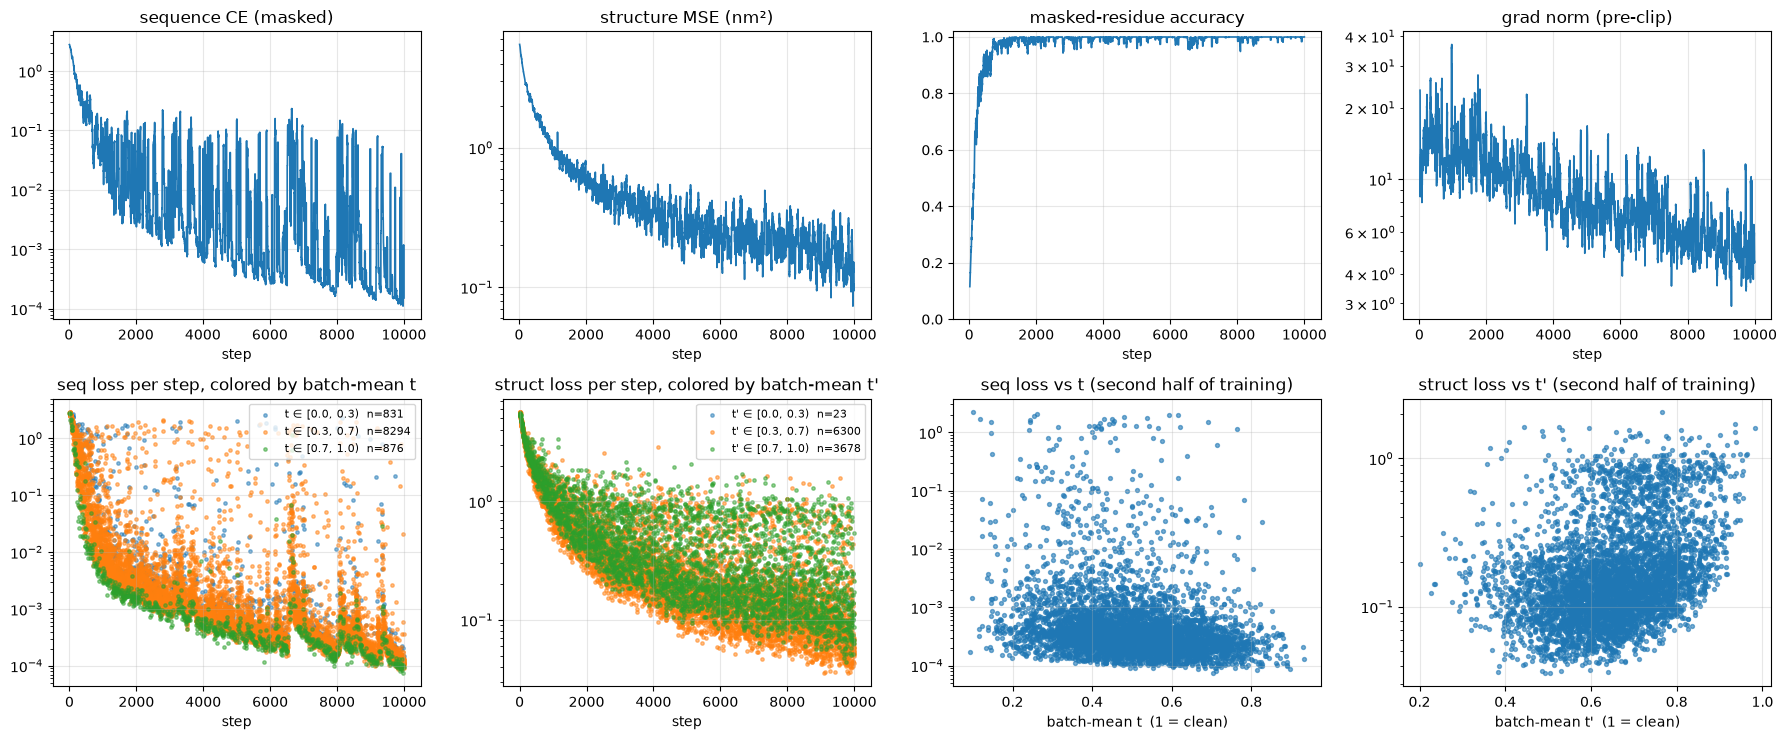

In [42]:
fig = plot_history(history, smooth=20)

### Interpretability

Now we can take a look at the attention patterns

In [43]:
store = {} 
handles = [
    layer.attn_probe.register_forward_hook(
        lambda mod, inp, out, i=i: store.__setitem__(i, out.detach().cpu()))
    for i, layer in enumerate(model.trunk.layers)
]
seq_t, coords_t, noise_mask, v_target, x0 = corrupt(batch, t, t_prime)
model.eval()
with torch.no_grad():
    model(seq_t, coords_t, batch["seq_mask"], batch["struct_mask"], batch["idx"], t, t_prime)
for h in handles:
    h.remove()

In [44]:
import math
from matplotlib.colors import LogNorm


def plot_attention(attn, batch, b=0, heads=None, log_scale=True, drop_special=False, ncols=5):
    """Heatmaps of one block's joint attention for protein `b`, one panel per head.

    attn: (B, H, 2L, 2L), e.g. store[0]. Rows are queries, columns keys, laid out as
    [sequence tokens | structure residues]; padding is removed using batch["seq_mask"] and
    batch["struct_mask"]. drop_special=True also removes <cls>/<eos> from the sequence part.
    log_scale: log colors (attention is very peaked), floored at 1e-4.
    """
    a_all = attn[b].float().cpu()
    L = a_all.shape[-1] // 2
    seq_mask, struct_mask = batch["seq_mask"][b].cpu(), batch["struct_mask"][b].cpu()
    seq_keep = seq_mask.nonzero().squeeze(-1)
    if drop_special:
        seq_keep = seq_keep[struct_mask[seq_keep]]        # residues only
    struct_keep = struct_mask.nonzero().squeeze(-1) + L   # structure slots start at L
    keep = torch.cat([seq_keep, struct_keep])
    n_seq, n_struct = len(seq_keep), len(struct_keep)

    heads = list(range(a_all.shape[0])) if heads is None else list(heads)
    nrows = math.ceil(len(heads) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.0 * ncols, 3.0 * nrows),
                             squeeze=False, constrained_layout=True)
    norm = LogNorm(vmin=1e-4, vmax=1.0) if log_scale else None
    for ax, h in zip(axes.flat, heads):
        a = a_all[h][keep][:, keep]
        im = ax.imshow(a.clamp(min=1e-4) if log_scale else a, cmap="viridis", norm=norm,
                       interpolation="nearest")
        ax.axhline(n_seq - 0.5, color="white", lw=0.8)    # modality boundary
        ax.axvline(n_seq - 0.5, color="white", lw=0.8)
        ticks, labels = [n_seq / 2, n_seq + n_struct / 2], ["seq", "struct"]
        ax.set_xticks(ticks, labels, fontsize=8)
        ax.set_yticks(ticks, labels, fontsize=8, rotation=90, va="center")
        ax.set_title(f"head {h}", fontsize=9)
    for ax in axes.flat[len(heads):]:
        ax.axis("off")
    fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6, label="attention weight")
    fig.suptitle(f"{batch['ids'][b]}: rows = queries, cols = keys  [seq | struct]")
    return fig

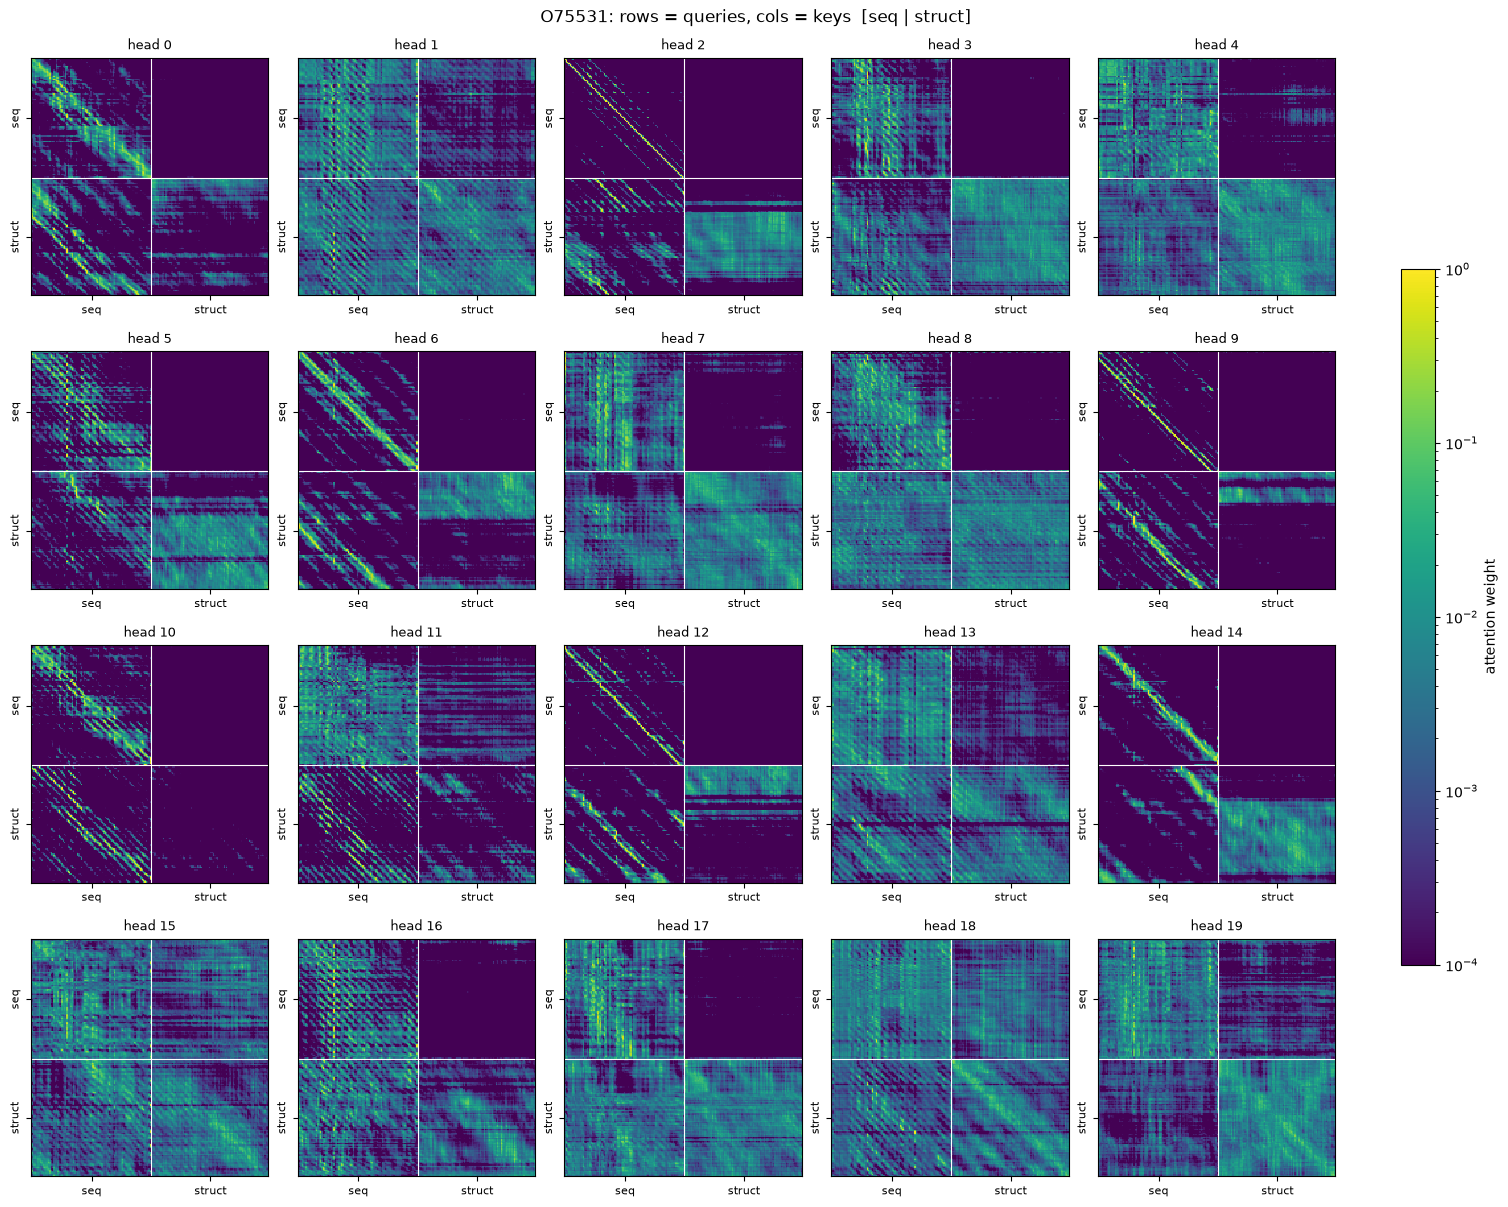

In [45]:
fig = plot_attention(store[5], batch, b=0)
fig.savefig("attn_patterns_q9UI30_l6.png", dpi=150)